In [1]:
# Cell 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [2]:
# Cell 2 - Load Cleaned Dataset
df = pd.read_csv(r'../data/cleaned_fraud_data.csv')

print("Cleaned dataset loaded!")
print(f"Shape: {df.shape}")
display(df.head())

Cleaned dataset loaded!
Shape: (51000, 10)


,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,1292.76,0,16.0,2,6,0,119,13,1,0
1,1554.58,0,13.0,1,5,4,79,3,0,0
2,2395.02,0,12.0,1,0,3,115,9,4,0
3,100.10,2,15.0,0,1,4,3,4,4,0
4,1490.50,4,19.0,1,6,2,57,7,0,0


In [3]:
# Cell 3 - Split Features and Target
# X = everything the model learns FROM
# y = what the model is trying to PREDICT

X = df.drop(columns=['Fraudulent'])
y = df['Fraudulent']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print()
print("Columns used to train:", X.columns.tolist())
print()
print("What we are predicting:")
print(y.value_counts())

Features (X) shape: (51000, 9)
Target (y) shape: (51000,)

Columns used to train: ['Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method']

What we are predicting:
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


In [4]:
# Cell 4 - Fix Class Imbalance with SMOTE
print("BEFORE SMOTE:")
print(y.value_counts())
print(f"Fraud %: {(y.sum()/len(y)*100):.2f}%")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAFTER SMOTE:")
print(pd.Series(y_resampled).value_counts())
print(f"Fraud %: {(y_resampled.sum()/len(y_resampled)*100):.2f}%")

BEFORE SMOTE:
Fraudulent
0    48490
1     2510
Name: count, dtype: int64
Fraud %: 4.92%

AFTER SMOTE:
Fraudulent
0    48490
1    48490
Name: count, dtype: int64
Fraud %: 50.00%


In [5]:
# Cell 5 - Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print(f"Training data size:  {X_train.shape}")
print(f"Testing data size:   {X_test.shape}")
print()
print("Think of it like this:")
print(f"  80% data ({X_train.shape[0]} rows) → model LEARNS from this")
print(f"  20% data ({X_test.shape[0]} rows) → we TEST the model on this")

Training data size:  (77584, 9)
Testing data size:   (19396, 9)

Think of it like this:
  80% data (77584 rows) → model LEARNS from this
  20% data (19396 rows) → we TEST the model on this


In [6]:
# Cell 6 - Train 3 Models
print("Training models... please wait...\n")

# Model 1: Logistic Regression (simplest)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print("Model 1: Logistic Regression - DONE")

# Model 2: Random Forest (medium complexity)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Model 2: Random Forest - DONE")

# Model 3: XGBoost (most powerful)
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
print("Model 3: XGBoost - DONE")

print("\nAll 3 models trained successfully!")

Training models... please wait...

Model 1: Logistic Regression - DONE
Model 2: Random Forest - DONE
Model 3: XGBoost - DONE

All 3 models trained successfully!


In [7]:
# Cell 7 - Compare All Models
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Accuracy': f"{acc*100:.2f}%",
        'ROC-AUC Score': f"{roc:.4f}"
    })

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy:      {acc*100:.2f}%")
    print(f"ROC-AUC Score: {roc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Normal', 'Fraud']))

results_df = pd.DataFrame(results)
print("\n=== FINAL COMPARISON ===")
display(results_df)


Model: Logistic Regression
Accuracy:      63.15%
ROC-AUC Score: 0.6797

Classification Report:
              precision    recall  f1-score   support

      Normal       0.64      0.61      0.63      9734
       Fraud       0.63      0.65      0.64      9662

    accuracy                           0.63     19396
   macro avg       0.63      0.63      0.63     19396
weighted avg       0.63      0.63      0.63     19396


Model: Random Forest
Accuracy:      91.62%
ROC-AUC Score: 0.9711

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.89      0.91      9734
       Fraud       0.90      0.94      0.92      9662

    accuracy                           0.92     19396
   macro avg       0.92      0.92      0.92     19396
weighted avg       0.92      0.92      0.92     19396


Model: XGBoost
Accuracy:      92.17%
ROC-AUC Score: 0.9679

Classification Report:
              precision    recall  f1-score   support

      Normal       0.

,Model,Accuracy,ROC-AUC Score
0,Logistic Regression,63.15%,0.6797
1,Random Forest,91.62%,0.9711
2,XGBoost,92.17%,0.9679


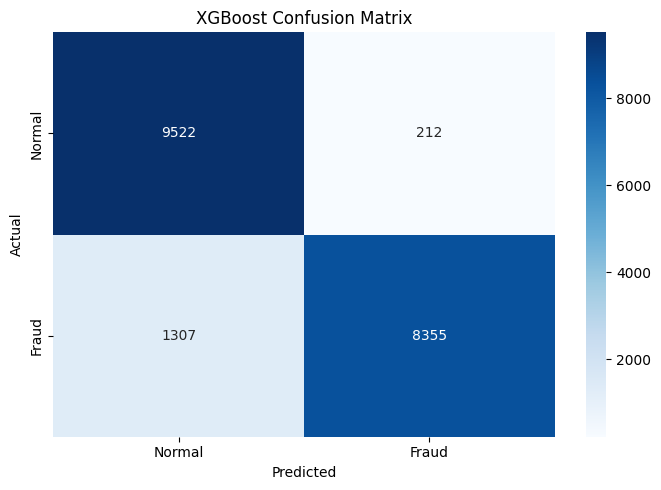

True Negatives  (correctly said Normal): 9522
False Positives (wrongly said Fraud):    212
False Negatives (missed real Fraud):     1307
True Positives  (correctly caught Fraud):8355


In [8]:
# Cell 8 - Confusion Matrix (for XGBoost)
y_pred_xgb = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly said Normal): {tn}")
print(f"False Positives (wrongly said Fraud):    {fp}")
print(f"False Negatives (missed real Fraud):     {fn}")
print(f"True Positives  (correctly caught Fraud):{tp}")

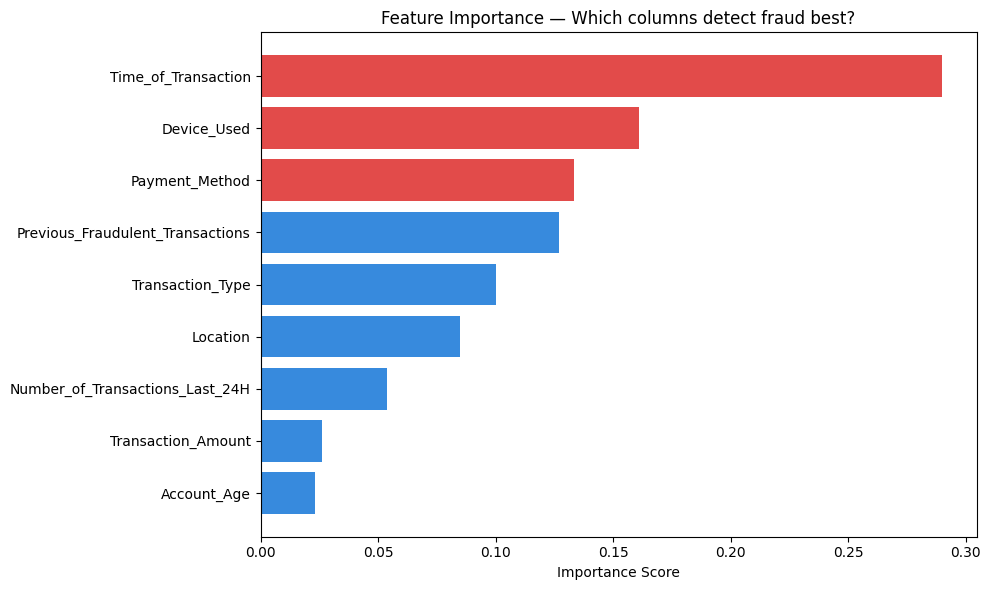

Top 3 most important features:
            Feature  Importance
Time_of_Transaction    0.290140
        Device_Used    0.161031
     Payment_Method    0.133465


In [10]:
# Cell 9 - Feature Importance (which columns matter most?)
feat_importance = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#E24B4A' if i < 3 else '#378ADD' for i in range(len(feat_importance))]
plt.barh(feat_importance['Feature'],  feat_importance['Importance'],  color=colors)
plt.xlabel('Importance Score')
plt.title('Feature Importance — Which columns detect fraud best?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
print(feat_importance.head(3).to_string(index=False))

In [13]:
# Cell 10 - Save the Best Model
joblib.dump(xgb_model, r'../models/fraud_model.pkl')
joblib.dump(X.columns.tolist(), r'../models/feature_names.pkl')

print("Model saved successfully!")
print("Location: C:/projects/fraud_detection/models/fraud_model.pkl")
print()
print("This saved model will be loaded by your Streamlit dashboard")
print("so it can make predictions without retraining every time!")

Model saved successfully!
Location: C:/projects/fraud_detection/models/fraud_model.pkl

This saved model will be loaded by your Streamlit dashboard
so it can make predictions without retraining every time!


In [14]:
import joblib
model = joblib.load('C:/projects/fraud_detection/models/fraud_model.pkl')
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>
